# Data Ingestion

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_excel("../Dataset/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df = df.drop(columns=["CustomerID"])
df.head()

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Data Cleaning And Outliner Handling

In [5]:
df.isna().sum()

Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

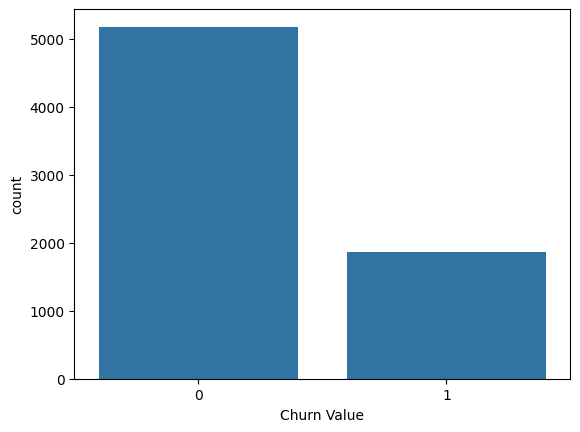

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Churn Value")
plt.show()


In [10]:

cols = df.columns.tolist()
numerical_cols = []
categorical_cols = []

for col in cols:
    if df[col].dtype == np.int64 or df[col].dtype == np.float64 or df[col].dtype==np.float32:
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)
    
    print("\n"*2)
    print(f"{col} has these unique values: {df[col].unique()}")
    print("="*60)





Count has these unique values: [1]



Country has these unique values: <StringArray>
['United States']
Length: 1, dtype: str



State has these unique values: <StringArray>
['California']
Length: 1, dtype: str



City has these unique values: <StringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str



Zip Code has these unique values: [90003 90005 90006 ... 96128 96134 96146]



Lat Long has these unique values: <StringArray>
['33.964131, -118.272783',  '34.059281, -118.30742', '34.048013, -118.293953',
 '34.062125, -118.315709', '34.039224, -118.266293', '34.066367, -118.309868',
  '34.02381, -118.156582', '34.06630

In [11]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors='coerce').astype("float64")

In [13]:
df[df['Total Charges'].isna()]

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [14]:
df[df["Churn Value"]==0].describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,5174.0,5174.000000,5174.000000,5174.000000,5174.000000,5174.000000,5163.000000,5174.0,5174.000000,5174.000000
mean,1.0,93518.212215,36.287436,-119.804838,37.569965,61.265124,2555.344141,0.0,50.098183,4490.921337
std,0.0,1868.429496,2.449340,2.156210,24.113777,31.092648,2329.456984,0.0,17.702277,1167.703198
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.0,5.000000,2003.000000
25%,1.0,92091.000000,34.029076,-121.823565,15.000000,25.100000,577.825000,0.0,35.000000,3643.750000
50%,1.0,93551.000000,36.414414,-119.739935,38.000000,64.425000,1683.600000,0.0,50.000000,4620.000000
75%,1.0,95345.750000,38.227285,-118.049237,61.000000,88.400000,4264.125000,0.0,66.000000,5434.750000
max,1.0,96148.000000,41.962127,-114.192901,72.000000,118.750000,8672.450000,0.0,80.000000,6500.000000


In [15]:
df["Total Charges"]=df["Total Charges"].fillna(2555)

In [18]:

cols = df.columns.tolist()
numerical_cols = []
categorical_cols = []

for col in cols:
    if df[col].dtype == np.int64 or df[col].dtype == np.float64:
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)

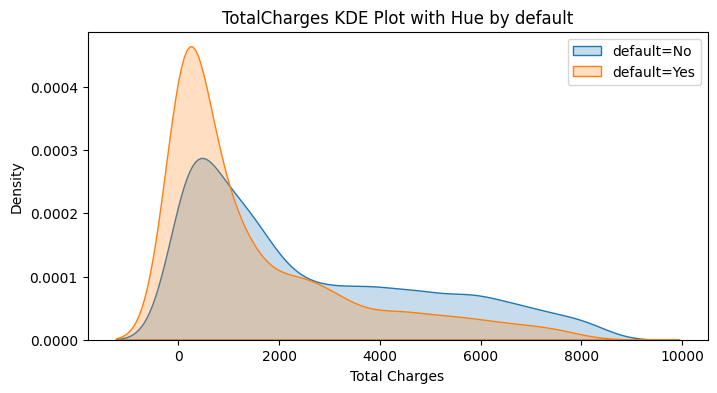

In [19]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df["Total Charges"][df['Churn Label'] == "No"], fill=True, label='default=No')
sns.kdeplot(df["Total Charges"][df['Churn Label'] == "Yes"], fill=True, label='default=Yes')
plt.title(f"TotalCharges KDE Plot with Hue by default")
plt.legend()
plt.show()

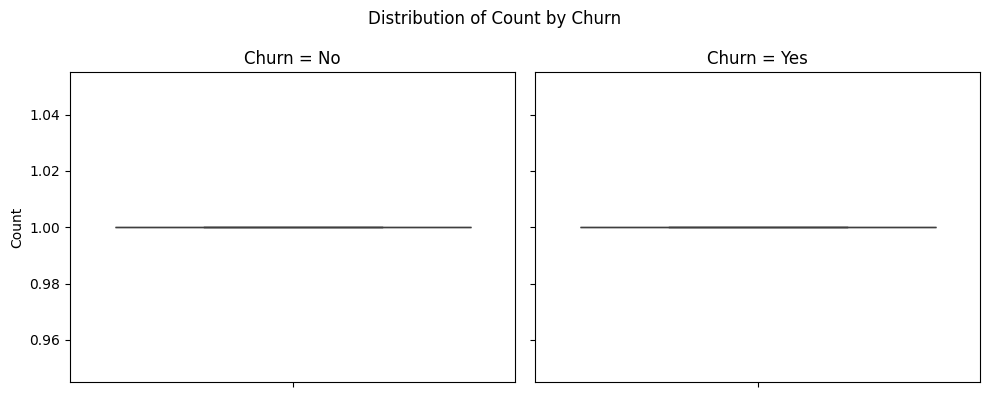

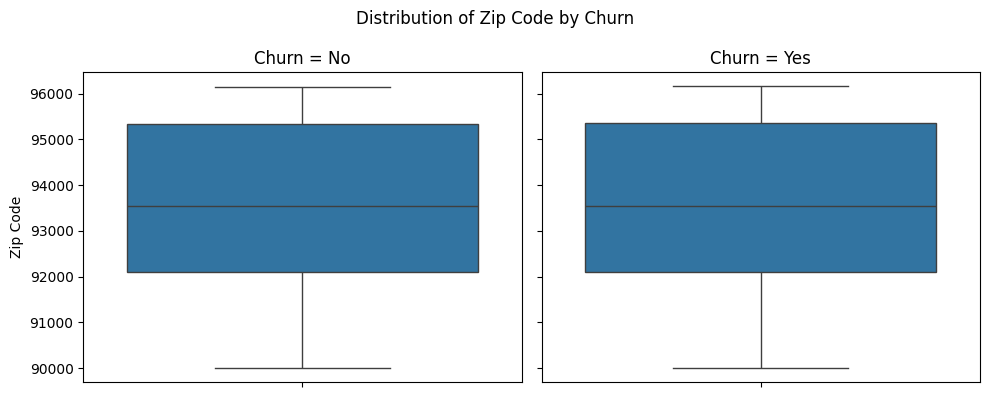

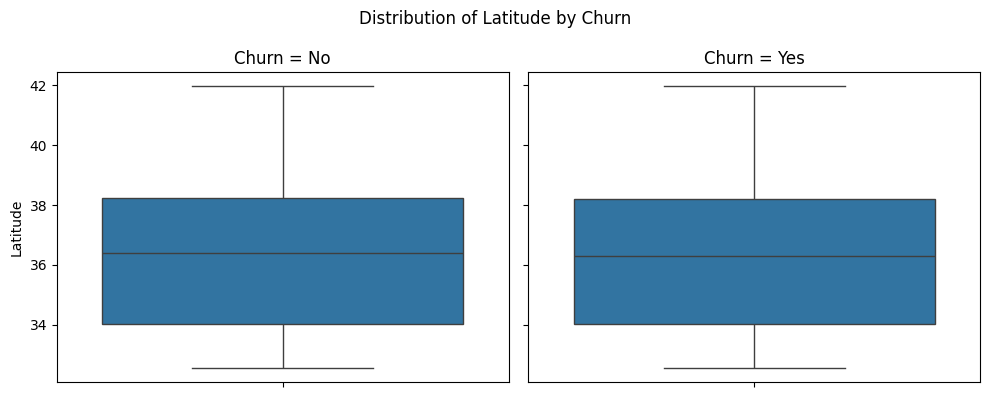

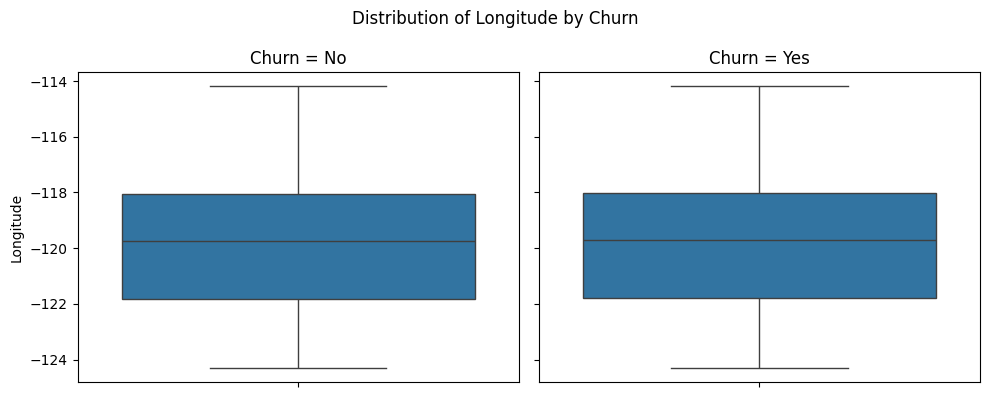

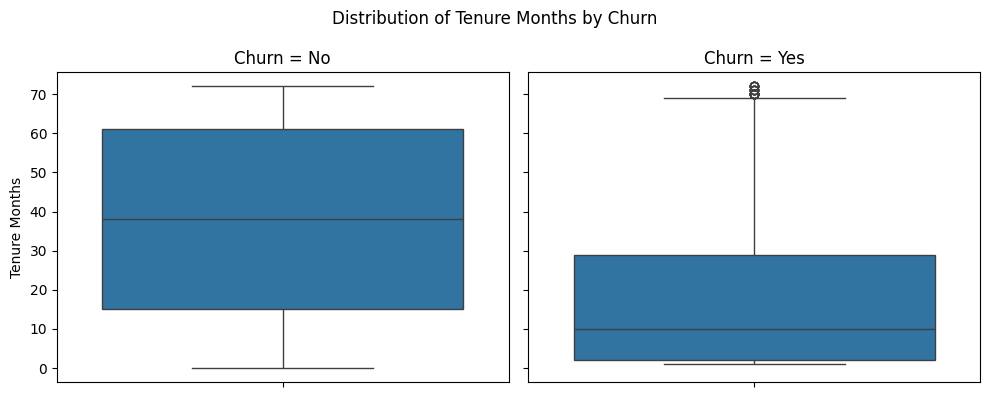

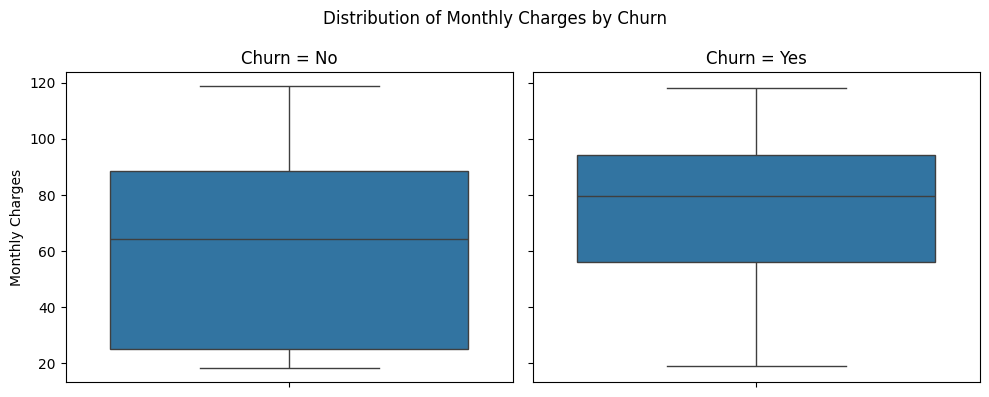

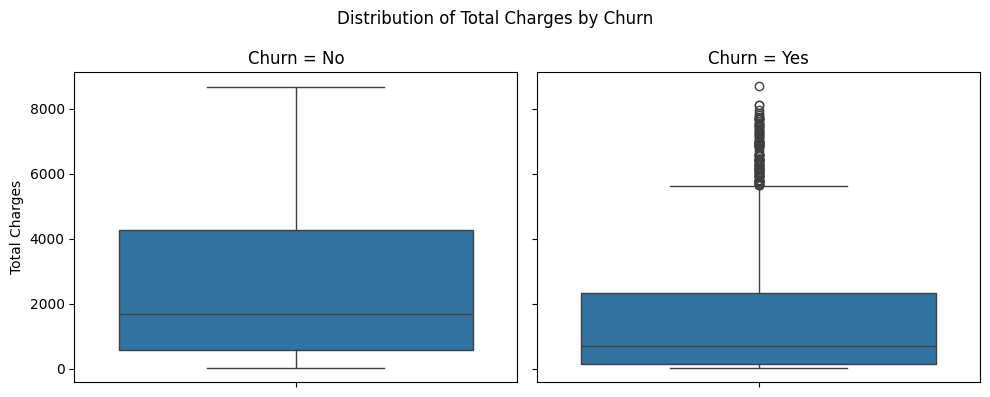

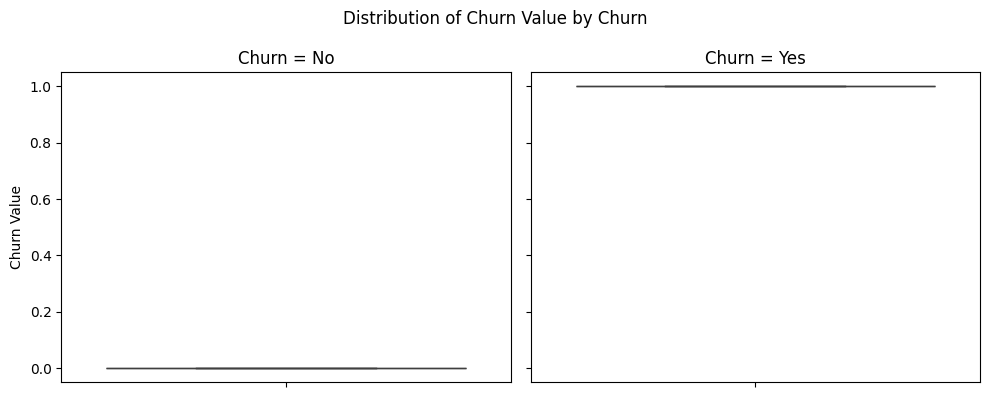

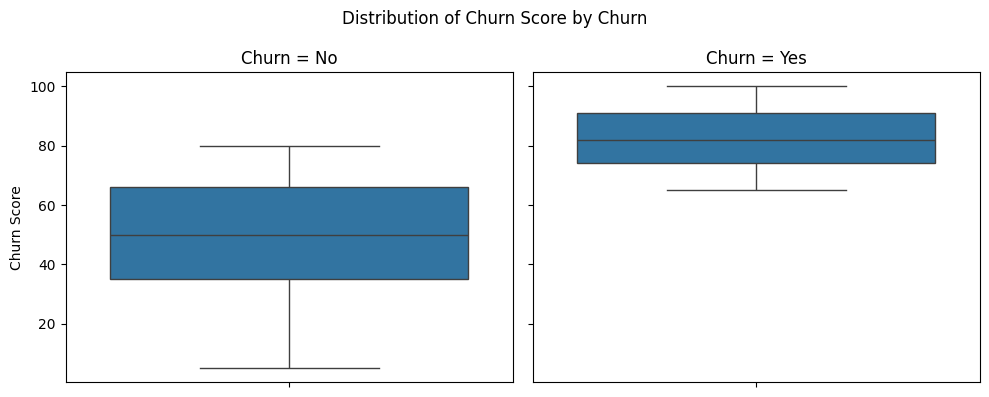

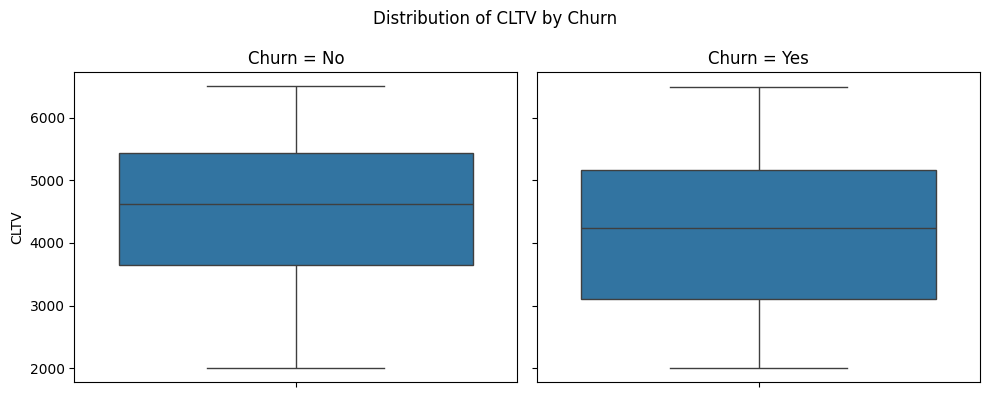

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    sns.boxplot(
        data=df[df["Churn Label"] == "No"],
        y=col,
        ax=axes[0],
        fill=True
    )
    axes[0].set_title("Churn = No")

    sns.boxplot(
        data=df[df["Churn Label"] == "Yes"],
        y=col,
        ax=axes[1],
        fill=True
    )
    axes[1].set_title("Churn = Yes")

    fig.suptitle(f"Distribution of {col} by Churn", fontsize=12)
    plt.tight_layout()
    plt.show()


In [22]:
def get_iqr_bounds(data):
    Q1,Q3=data.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    return lower_bound,upper_bound

In [23]:
lower_bound,upper_bound=get_iqr_bounds(df[df["Churn Label"]=="Yes"]["Total Charges"])

In [24]:
lower_bound,upper_bound

(-3160.7000000000003, 5626.5)

In [26]:
mask = (df["Churn Label"] == "Yes") & (df["Total Charges"] > upper_bound)

mean_yes = df.loc[df["Churn Label"] == "Yes", "Total Charges"].mean()

df.loc[mask, "Total Charges"] = mean_yes

In [27]:
mean_no = df[df["Churn Label"] == "No"]["Total Charges"].mean()
df.loc[df['Total Charges'].isna(), "Total Charges"] = mean_no

# Data Visualization

/tmp/ipykernel_4042/3318561882.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col][df['Churn Label'] == "No"], fill=True, label='default=No')
/tmp/ipykernel_4042/3318561882.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col][df['Churn Label'] == "Yes"], fill=True, label='default=Yes')
/tmp/ipykernel_4042/3318561882.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


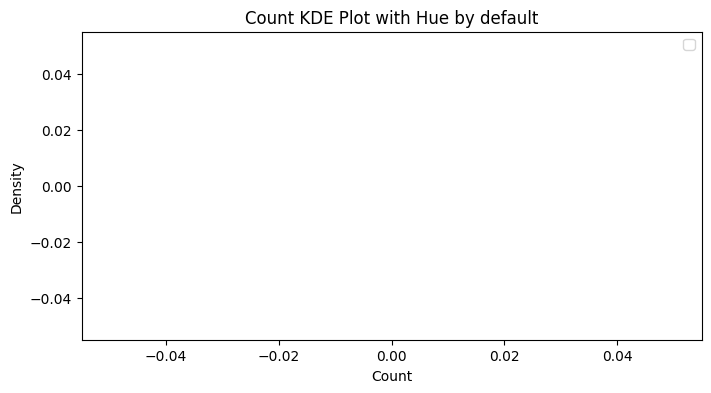

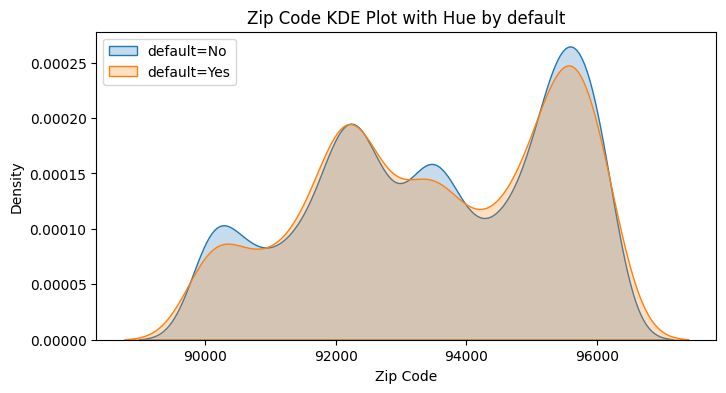

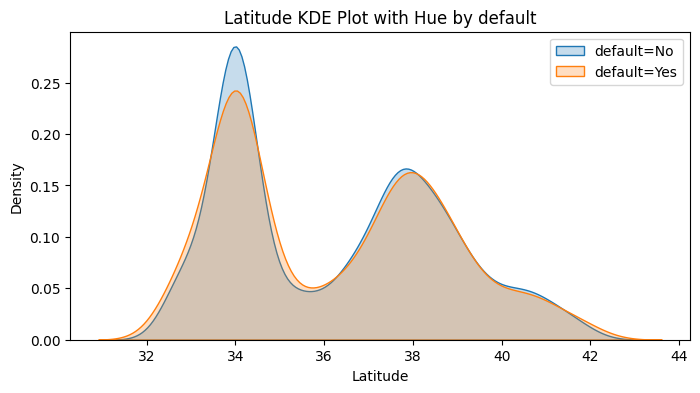

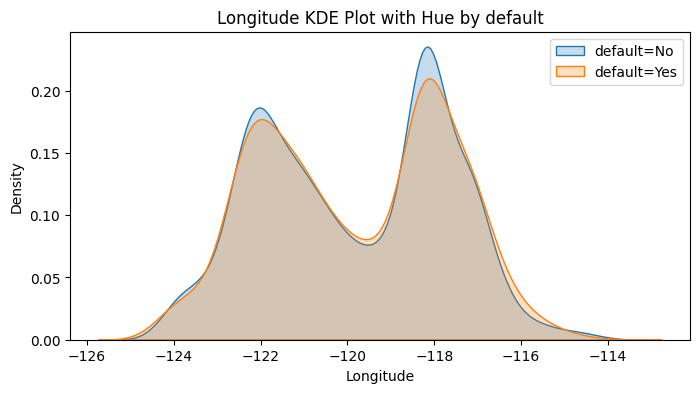

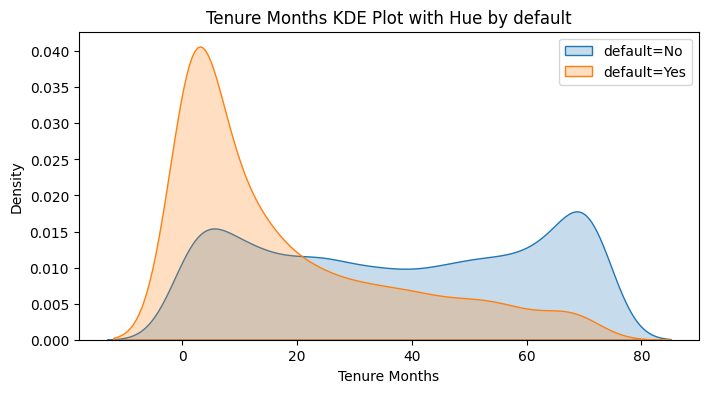

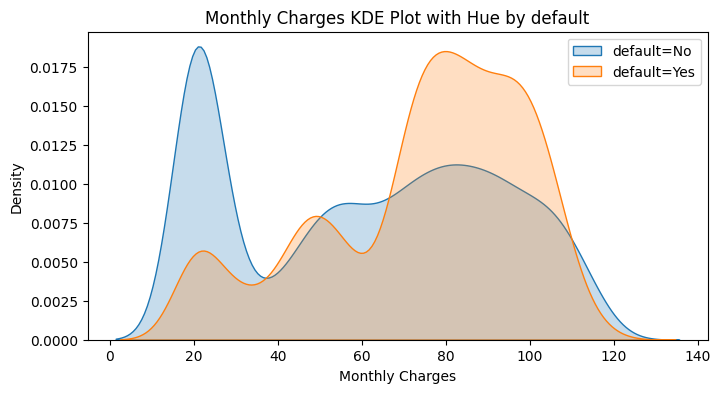

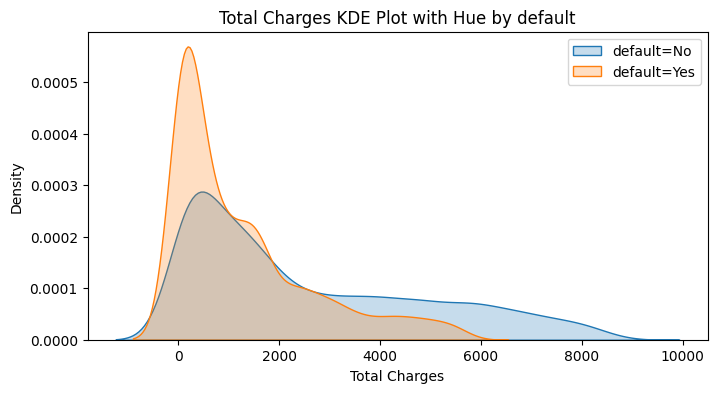

/tmp/ipykernel_4042/3318561882.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col][df['Churn Label'] == "No"], fill=True, label='default=No')
/tmp/ipykernel_4042/3318561882.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col][df['Churn Label'] == "Yes"], fill=True, label='default=Yes')
/tmp/ipykernel_4042/3318561882.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


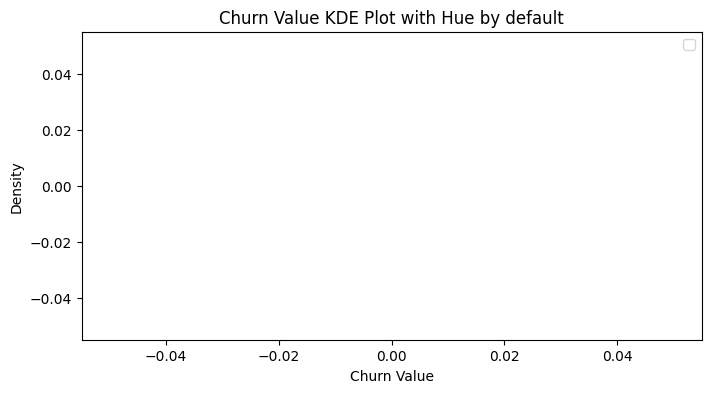

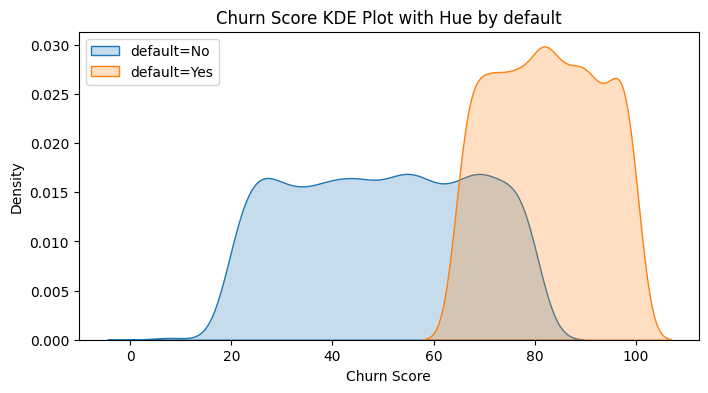

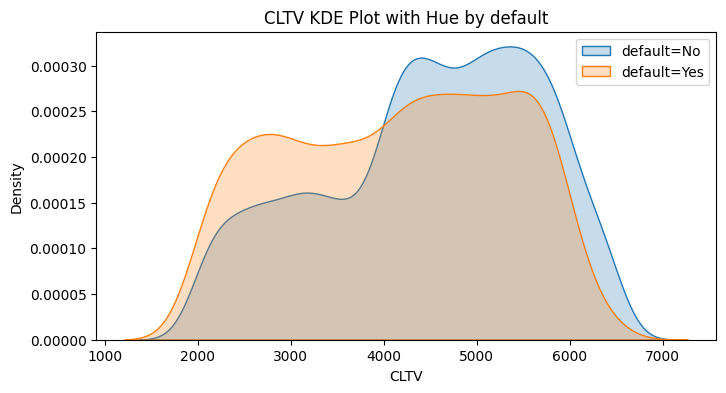

In [30]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df[col][df['Churn Label'] == "No"], fill=True, label='default=No')
    sns.kdeplot(df[col][df['Churn Label'] == "Yes"], fill=True, label='default=Yes')
    plt.title(f"{col} KDE Plot with Hue by default")
    plt.legend()
    plt.show()

In [35]:
categorical_cols

['Country',
 'State',
 'City',
 'Lat Long',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Churn Label',
 'Churn Reason']

In [36]:
categorical_cols.remove("Lat Long")
categorical_cols.remove("State")
categorical_cols.remove("City")
categorical_cols.remove("Churn Label")

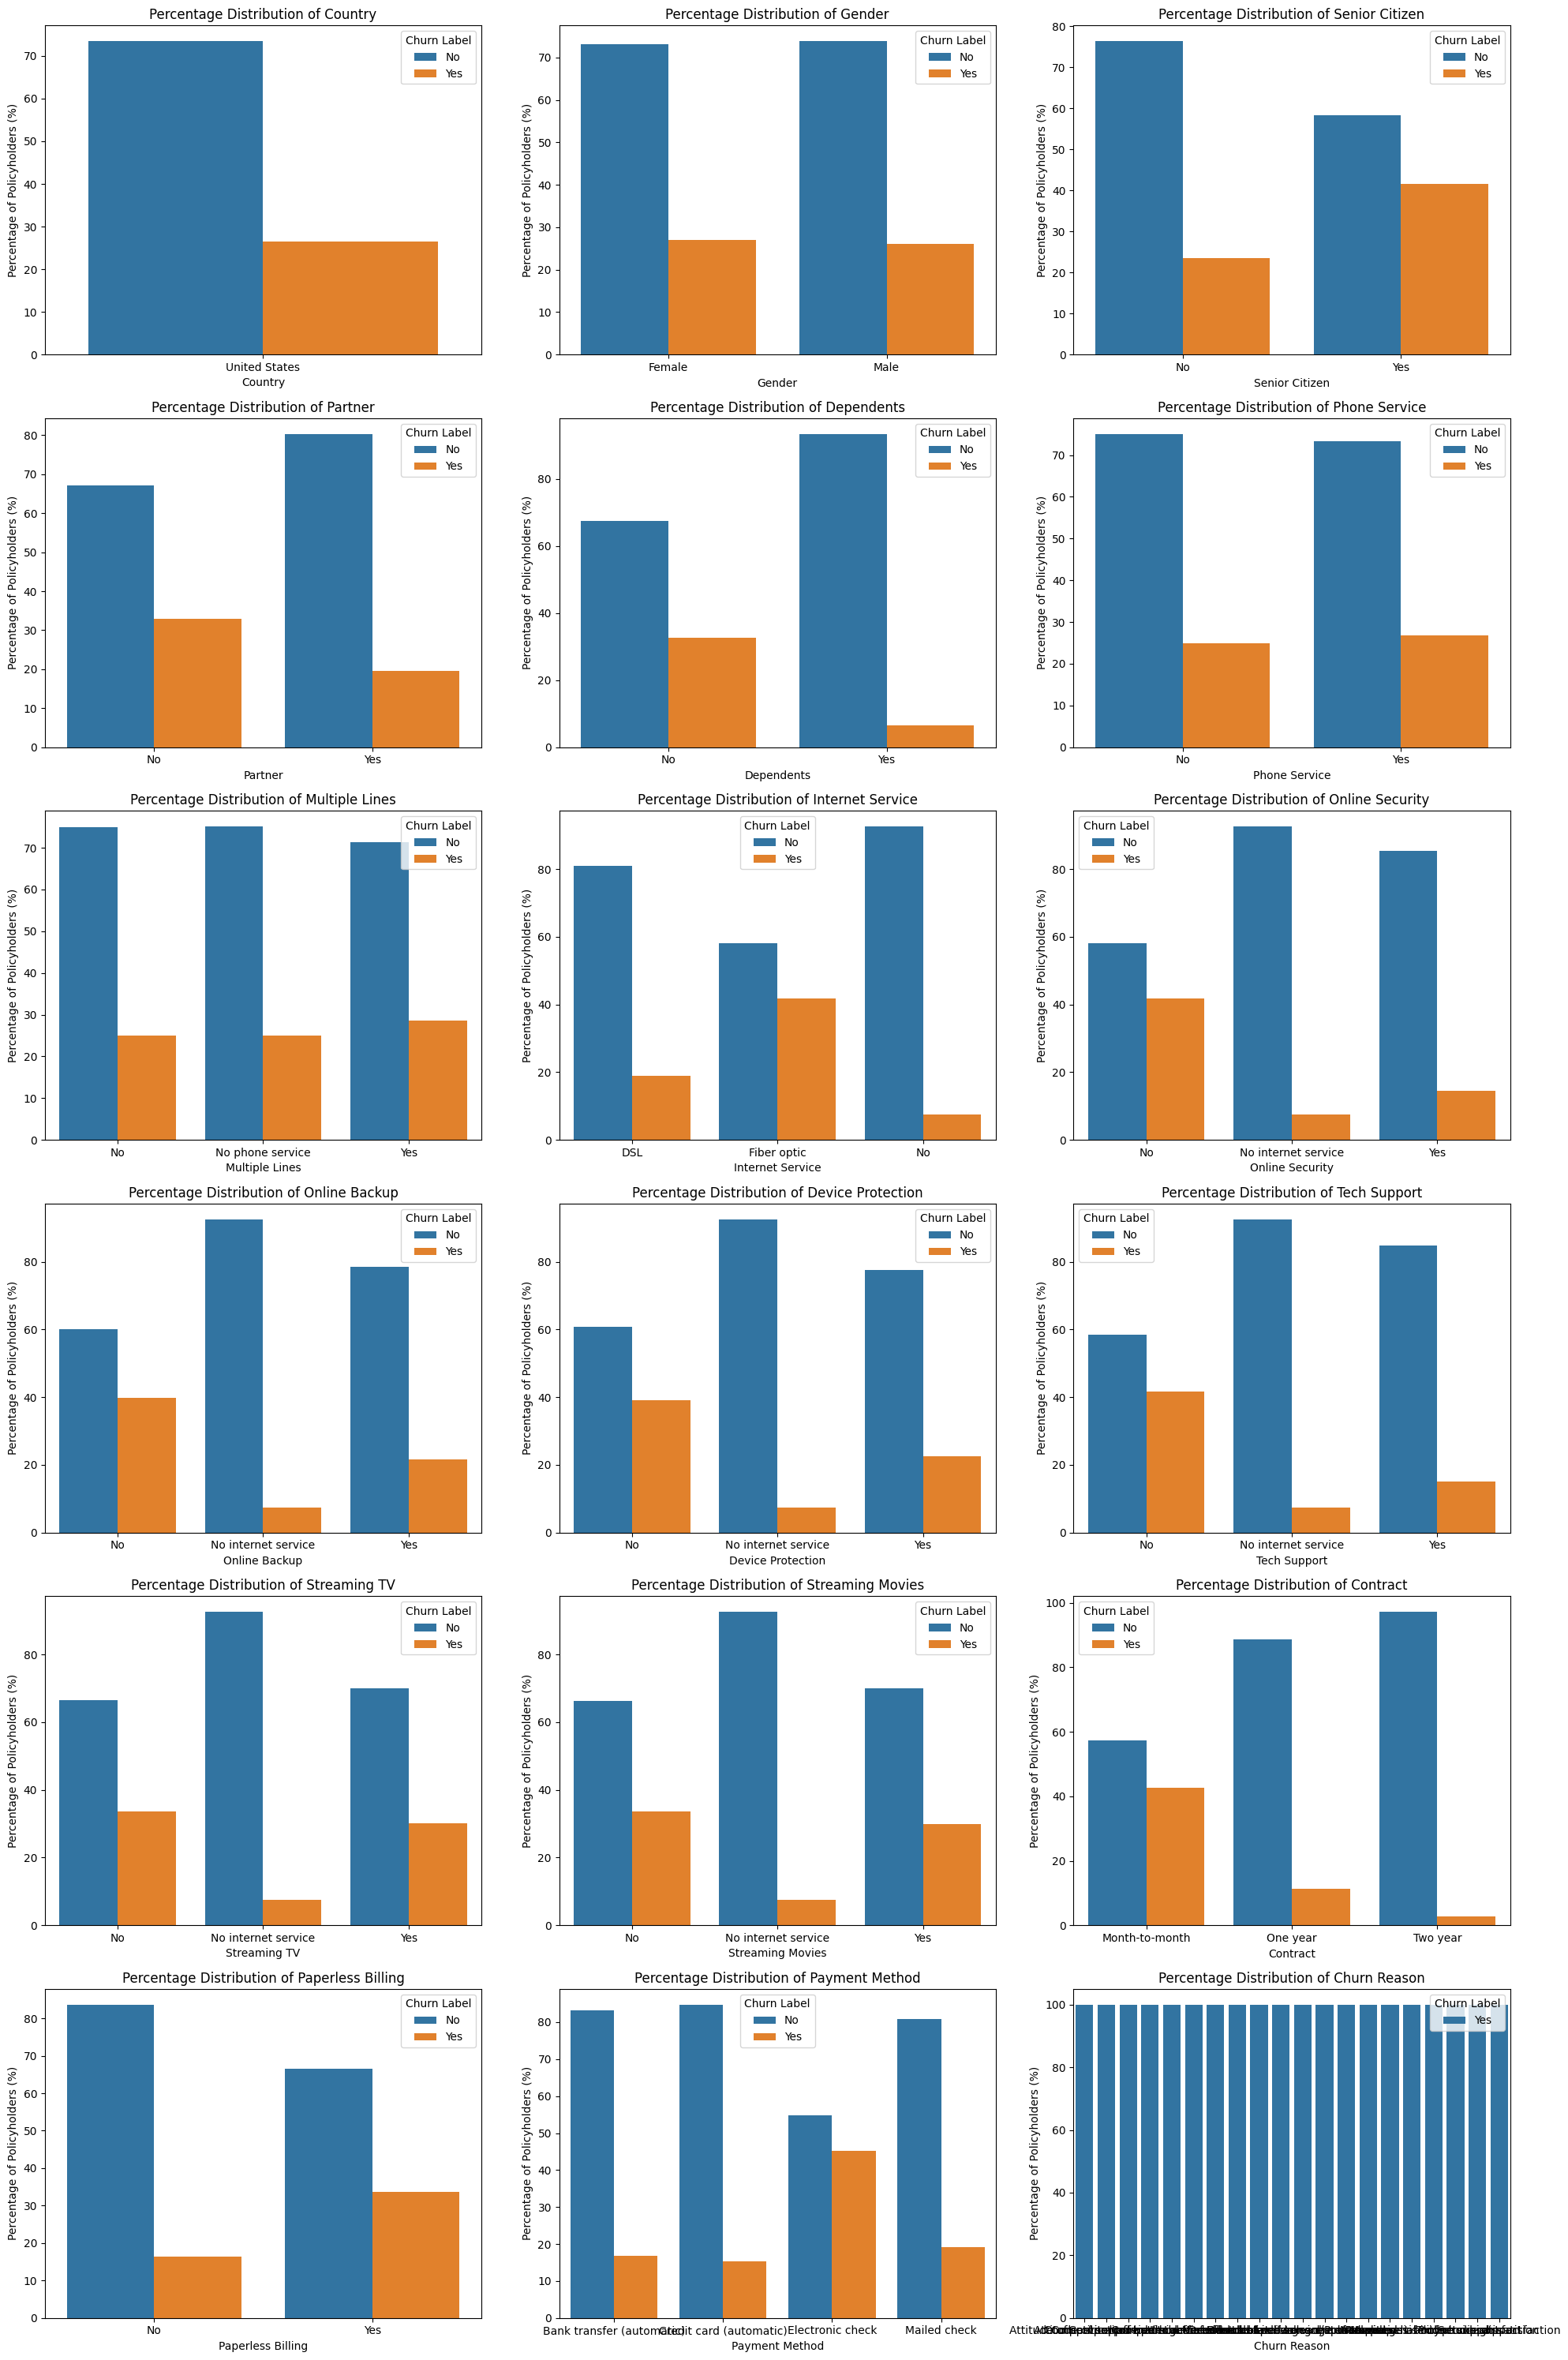

In [37]:
fig, axes = plt.subplots(6, 3, figsize=(20, 30))
axes = axes.flatten()

for ax, column in zip(axes, categorical_cols):
    # Count occurrences grouped by churn and the category
    count_data = df.groupby(['Churn Label', column]).size().reset_index(name='count')

    # Calculate percentage within each category (column)
    total_per_category = count_data.groupby(column)['count'].transform('sum')
    count_data['percentage'] = (count_data['count'] / total_per_category) * 100

    # Plot percentage distribution
    sns.barplot(data=count_data, x=column, y='percentage', hue='Churn Label', ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

### Feature Engineering And Selection

In [38]:
df.columns

Index(['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [39]:
dropping_col = ["Churn Label", "Count", "Country", "State", "City", "Latitude", "Longitude", "Lat Long", "Zip Code"]

df = df.drop(columns=dropping_col)

In [40]:
encoding_cols=["Phone Service","Dependents","Partner","Paperless Billing","Senior Citizen"]
one_hot_encoding=["Multiple Lines",'Internet Service', 'Online Security',"Gender",
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies','Contract','Payment Method']

In [41]:
for col in encoding_cols:
    df[col]=df[col].map({"No":0,"Yes":1})
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason
0,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,No,Month-to-month,1,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,Female,0,0,1,2,1,No,Fiber optic,No,No,...,No,Month-to-month,1,Electronic check,70.70,151.65,1,67,2701,Moved
2,Female,0,0,1,8,1,Yes,Fiber optic,No,No,...,Yes,Month-to-month,1,Electronic check,99.65,820.50,1,86,5372,Moved
3,Female,0,1,1,28,1,Yes,Fiber optic,No,No,...,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1,84,5003,Moved
4,Male,0,0,1,49,1,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   int64  
 2   Partner            7043 non-null   int64  
 3   Dependents         7043 non-null   int64  
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   int64  
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   int64  
 16  Payment Method     7043 non-null   

In [44]:
df = df.drop(columns=["Churn Reason"])

In [45]:
scores = df["Churn Score"]
df = df.drop(columns=["Churn Score"])

In [46]:
df1=df.copy()
col1=df.drop("Churn Value",axis=1).columns.tolist()
df1 = pd.get_dummies(df1, columns=one_hot_encoding, drop_first=True, dtype=int)
df1

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,CLTV,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,0,0,0,2,1,1,53.85,108.15,1,3239,...,0,0,0,0,0,0,0,0,0,1
1,0,0,1,2,1,1,70.70,151.65,1,2701,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,8,1,1,99.65,820.50,1,5372,...,0,0,1,0,1,0,0,0,1,0
3,0,1,1,28,1,1,104.80,3046.05,1,5003,...,1,0,1,0,1,0,0,0,1,0
4,0,0,1,49,1,1,103.70,5036.30,1,5340,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,72,1,1,21.15,1419.40,0,5306,...,0,1,0,1,0,0,1,0,0,0
7039,0,1,1,24,1,1,84.80,1990.50,0,2140,...,1,0,1,0,1,1,0,0,0,1
7040,0,1,1,72,1,1,103.20,7362.90,0,5560,...,0,0,1,0,1,1,0,1,0,0
7041,0,1,1,11,0,1,29.60,346.45,0,2793,...,0,0,0,0,0,0,0,0,1,0


In [47]:
df1.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Paperless Billing', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'CLTV',
       'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Gender_Male', 'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='str')

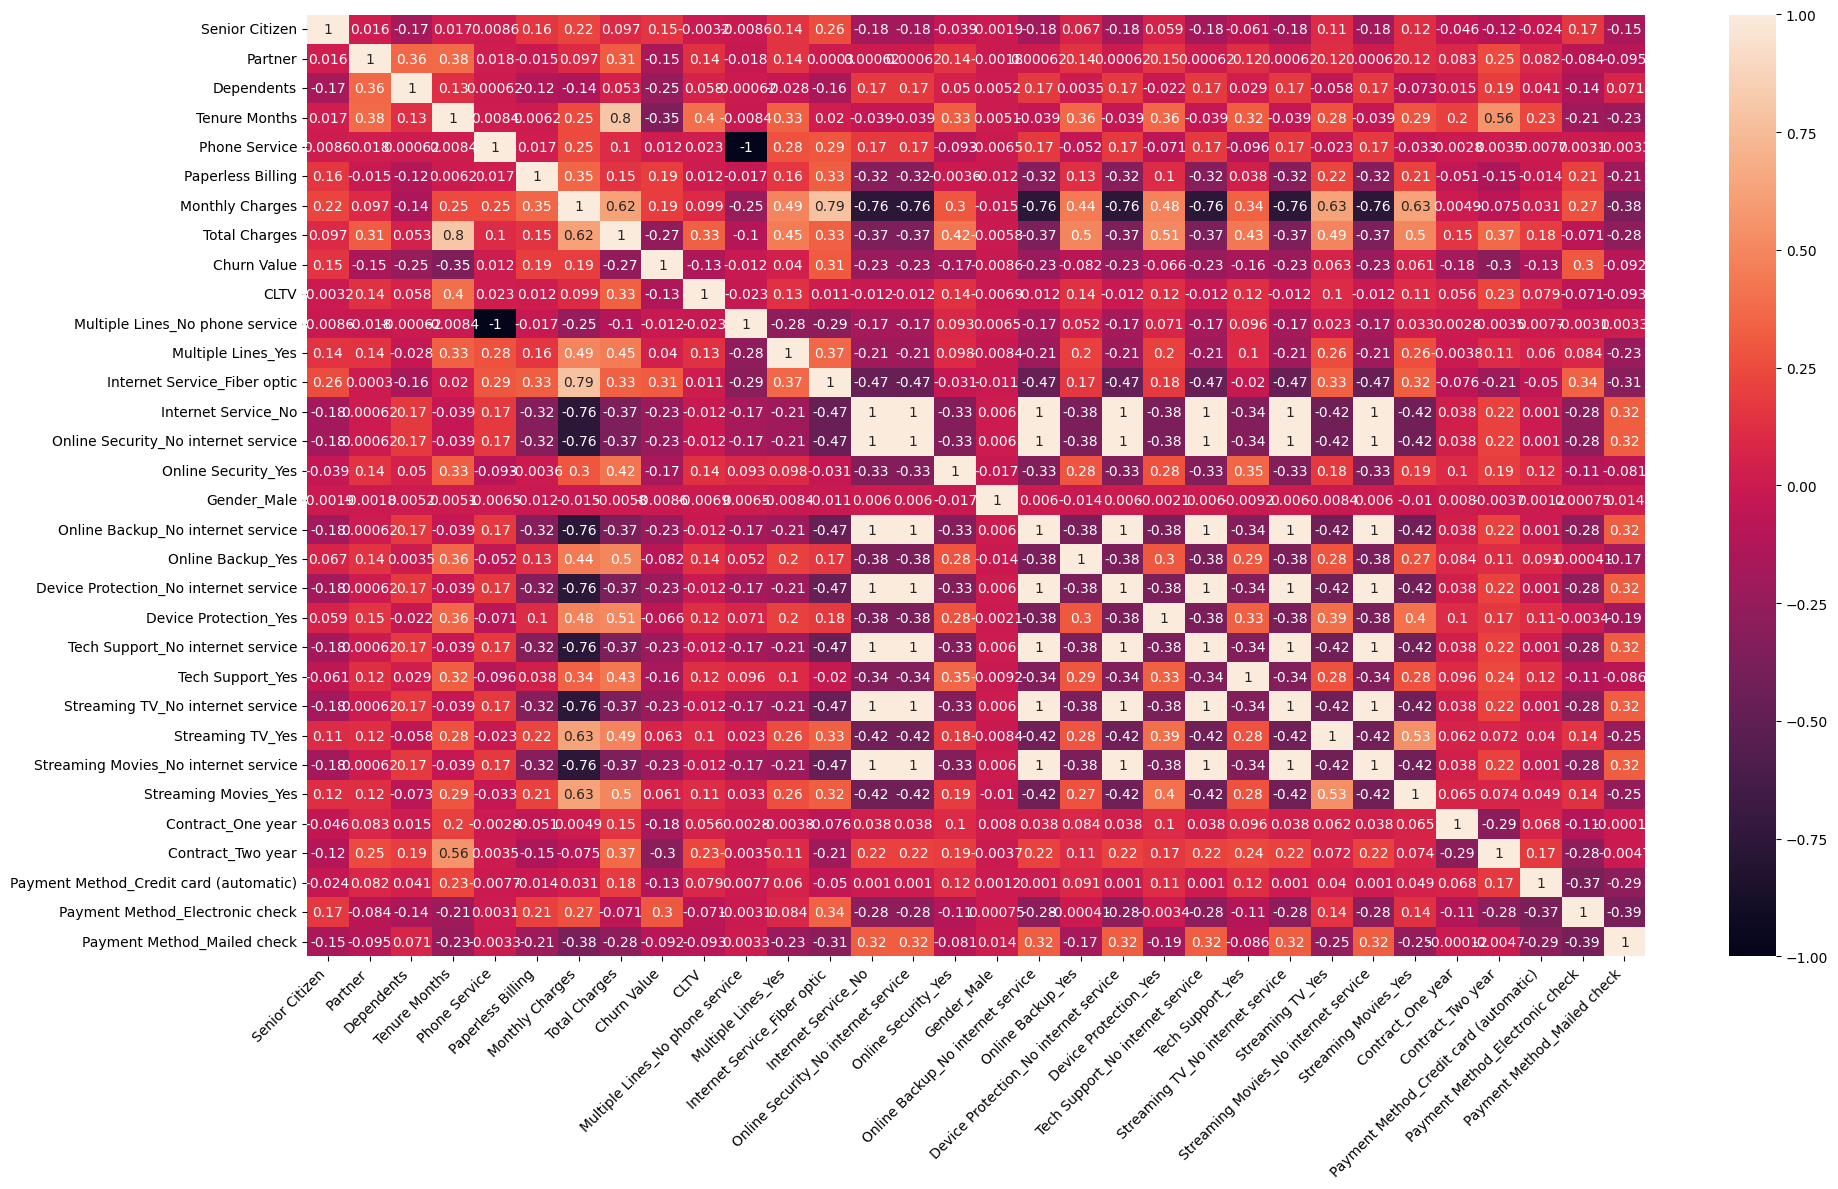

In [48]:
cm = df1.corr()
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
X=df1.drop("Churn Value",axis=1)
y=df1["Churn Value"]

In [50]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
mi_scores = mutual_info_classif(X, y)
mi_df = pd.DataFrame({"Feature": X.columns, "MI Score": mi_scores})
print(mi_df.sort_values(by="MI Score", ascending=False))

                                   Feature  MI Score
7                            Total Charges  0.086275
3                            Tenure Months  0.071226
27                       Contract_Two year  0.055519
11            Internet Service_Fiber optic  0.048852
6                          Monthly Charges  0.047521
29         Payment Method_Electronic check  0.043318
22        Streaming TV_No internet service  0.037381
13     Online Security_No internet service  0.034804
20        Tech Support_No internet service  0.034511
2                               Dependents  0.031644
12                     Internet Service_No  0.027463
16       Online Backup_No internet service  0.027383
24    Streaming Movies_No internet service  0.025313
18   Device Protection_No internet service  0.024999
5                        Paperless Billing  0.024769
21                        Tech Support_Yes  0.022561
26                       Contract_One year  0.019761
14                     Online Security_Yes  0.

In [ ]:
df1.describe()

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,CLTV,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.231010,32.371149,0.903166,0.592219,64.761692,2204.199748,0.265370,4400.295755,...,0.290217,0.216669,0.384353,0.216669,0.387903,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.368612,0.499748,0.421508,24.559481,0.295752,0.491457,30.090047,2197.159816,0.441561,1183.057152,...,0.453895,0.412004,0.486477,0.412004,0.487307,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,2003.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,0.000000,3469.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1400.550000,0.000000,4527.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,55.000000,1.000000,1.000000,89.850000,3569.150000,1.000000,5380.500000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8672.450000,1.000000,6500.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [55]:
numerical_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV", ]

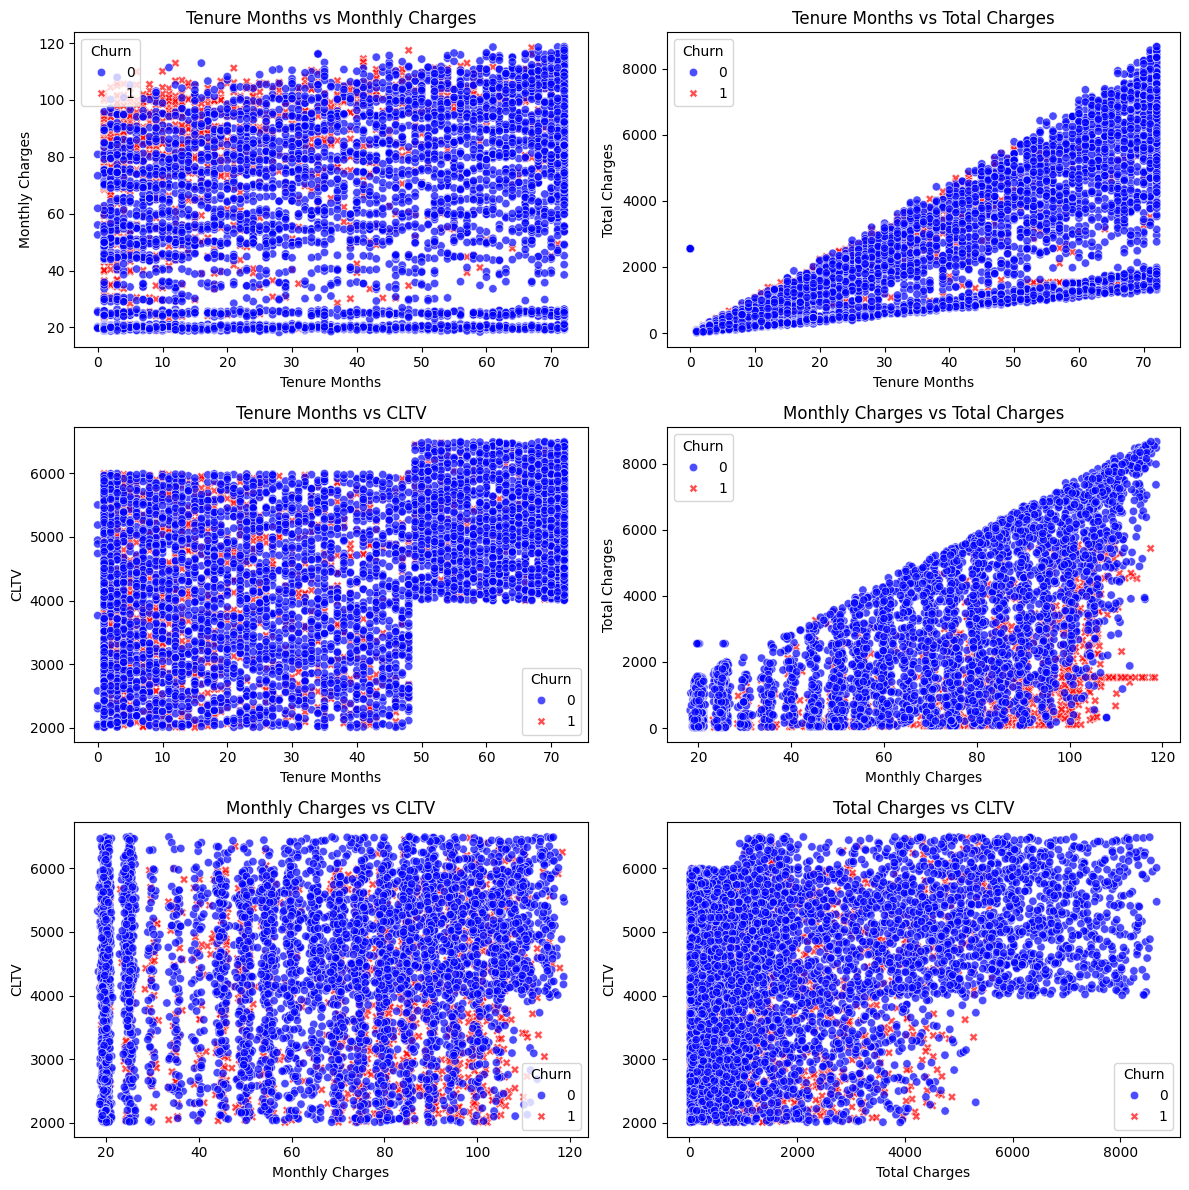

In [56]:
import math
pairs = []
for i in range(0, 4):
    for j in range(i + 1, 4):
        pairs.append((numerical_cols[i], numerical_cols[j]))

ncols = 2
nrows = math.ceil(len(pairs) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="Churn Value",
        style="Churn Value",
        palette={1: "red", 0: "blue"},
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend(title="Churn")

# Remove empty subplots
for ax in axes[len(pairs):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [57]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

poly_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV", ]

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly_array = poly.fit_transform(X[poly_cols])

In [58]:
X_poly_array

array([[2.00000000e+00, 5.38500000e+01, 1.08150000e+02, ...,
        1.16964225e+04, 3.50297850e+05, 1.04911210e+07],
       [2.00000000e+00, 7.07000000e+01, 1.51650000e+02, ...,
        2.29977225e+04, 4.09606650e+05, 7.29540100e+06],
       [8.00000000e+00, 9.96500000e+01, 8.20500000e+02, ...,
        6.73220250e+05, 4.40772600e+06, 2.88583840e+07],
       ...,
       [7.20000000e+01, 1.03200000e+02, 7.36290000e+03, ...,
        5.42122964e+07, 4.09377240e+07, 3.09136000e+07],
       [1.10000000e+01, 2.96000000e+01, 3.46450000e+02, ...,
        1.20027602e+05, 9.67634850e+05, 7.80084900e+06],
       [6.60000000e+01, 1.05650000e+02, 6.84450000e+03, ...,
        4.68471802e+07, 3.48864165e+07, 2.59794090e+07]], shape=(7043, 14))

In [59]:
poly_feature_names = poly.get_feature_names_out(poly_cols)

X_poly_df = pd.DataFrame(
    X_poly_array,
    columns=poly_feature_names,
    index=X.index
)
X_poly_df

,Tenure Months,Monthly Charges,Total Charges,CLTV,Tenure Months^2,Tenure Months Monthly Charges,Tenure Months Total Charges,Tenure Months CLTV,Monthly Charges^2,Monthly Charges Total Charges,Monthly Charges CLTV,Total Charges^2,Total Charges CLTV,CLTV^2
0,2.0,53.85,108.15,3239.0,4.0,107.7,216.30,6478.0,2899.8225,5823.8775,174420.15,1.169642e+04,350297.85,10491121.0
1,2.0,70.70,151.65,2701.0,4.0,141.4,303.30,5402.0,4998.4900,10721.6550,190960.70,2.299772e+04,409606.65,7295401.0
2,8.0,99.65,820.50,5372.0,64.0,797.2,6564.00,42976.0,9930.1225,81762.8250,535319.80,6.732202e+05,4407726.00,28858384.0
3,28.0,104.80,3046.05,5003.0,784.0,2934.4,85289.40,140084.0,10983.0400,319226.0400,524314.40,9.278421e+06,15239388.15,25030009.0
4,49.0,103.70,5036.30,5340.0,2401.0,5081.3,246778.70,261660.0,10753.6900,522264.3100,553758.00,2.536432e+07,26893842.00,28515600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72.0,21.15,1419.40,5306.0,5184.0,1522.8,102196.80,382032.0,447.3225,30020.3100,112221.90,2.014696e+06,7531336.40,28153636.0
7039,24.0,84.80,1990.50,2140.0,576.0,2035.2,47772.00,51360.0,7191.0400,168794.4000,181472.00,3.962090e+06,4259670.00,4579600.0
7040,72.0,103.20,7362.90,5560.0,5184.0,7430.4,530128.80,400320.0,10650.2400,759851.2800,573792.00,5.421230e+07,40937724.00,30913600.0
7041,11.0,29.60,346.45,2793.0,121.0,325.6,3810.95,30723.0,876.1600,10254.9200,82672.80,1.200276e+05,967634.85,7800849.0


In [60]:
X_rest = X.drop(columns=poly_cols)

X_poly_final = pd.concat([X_rest, X_poly_df], axis=1)

In [61]:
X_poly_final

,Senior Citizen,Partner,Dependents,Phone Service,Paperless Billing,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,...,Tenure Months^2,Tenure Months Monthly Charges,Tenure Months Total Charges,Tenure Months CLTV,Monthly Charges^2,Monthly Charges Total Charges,Monthly Charges CLTV,Total Charges^2,Total Charges CLTV,CLTV^2
0,0,0,0,1,1,0,0,0,0,0,...,4.0,107.7,216.30,6478.0,2899.8225,5823.8775,174420.15,1.169642e+04,350297.85,10491121.0
1,0,0,1,1,1,0,0,1,0,0,...,4.0,141.4,303.30,5402.0,4998.4900,10721.6550,190960.70,2.299772e+04,409606.65,7295401.0
2,0,0,1,1,1,0,1,1,0,0,...,64.0,797.2,6564.00,42976.0,9930.1225,81762.8250,535319.80,6.732202e+05,4407726.00,28858384.0
3,0,1,1,1,1,0,1,1,0,0,...,784.0,2934.4,85289.40,140084.0,10983.0400,319226.0400,524314.40,9.278421e+06,15239388.15,25030009.0
4,0,0,1,1,1,0,1,1,0,0,...,2401.0,5081.3,246778.70,261660.0,10753.6900,522264.3100,553758.00,2.536432e+07,26893842.00,28515600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,1,1,0,0,0,1,1,...,5184.0,1522.8,102196.80,382032.0,447.3225,30020.3100,112221.90,2.014696e+06,7531336.40,28153636.0
7039,0,1,1,1,1,0,1,0,0,0,...,576.0,2035.2,47772.00,51360.0,7191.0400,168794.4000,181472.00,3.962090e+06,4259670.00,4579600.0
7040,0,1,1,1,1,0,1,1,0,0,...,5184.0,7430.4,530128.80,400320.0,10650.2400,759851.2800,573792.00,5.421230e+07,40937724.00,30913600.0
7041,0,1,1,0,1,1,0,0,0,0,...,121.0,325.6,3810.95,30723.0,876.1600,10254.9200,82672.80,1.200276e+05,967634.85,7800849.0


In [64]:
X_poly_final.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Paperless Billing', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Gender_Male',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check',
       'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV',
       'Tenure Months^2', 'Tenure Months Monthly Charges',
       'Tenure Months Total Charges', 'Tenure Months CLTV',
  

# Scaling

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold


In [68]:
X_scaled=X.copy()
scaler = StandardScaler()
X4_train,X4_test,y4_train,y4_test=train_test_split(X_scaled, y, test_size=0.30, random_state=10)
X4_train[poly_cols] = scaler.fit_transform(X4_train[poly_cols])
X4_test[poly_cols] = scaler.transform(X4_test[poly_cols])
X4_train

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,CLTV,Multiple Lines_No phone service,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
1768,1,0,0,-1.202563,1,0,0.882290,-0.870466,-1.864788,0,...,0,0,1,0,0,0,0,0,1,0
3556,1,0,0,-1.284144,1,0,-0.634681,-0.981544,0.149420,0,...,0,0,0,0,0,0,0,0,1,0
6018,0,0,1,0.265880,1,0,-1.288120,-0.565630,1.341709,0,...,0,1,0,1,0,1,0,0,0,0
2840,0,0,0,-1.039403,1,1,-1.470091,-0.934954,-0.903346,0,...,0,1,0,1,0,0,0,0,0,1
6705,0,1,0,1.530373,1,0,0.283442,1.395917,1.747595,0,...,1,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,0,0,0,-0.631502,1,1,0.993126,-0.265484,-1.331217,0,...,0,0,1,0,0,0,0,0,1,0
3441,0,1,1,-0.672292,1,0,-1.463473,-0.846671,0.737109,0,...,0,1,0,1,0,0,0,0,1,0
1344,0,1,0,-1.039403,1,1,-0.484142,-0.851248,1.058435,0,...,0,0,0,0,0,1,0,0,1,0
4623,1,0,0,1.611954,1,1,1.446398,2.538342,0.063169,0,...,1,0,1,0,1,0,1,0,0,0


In [73]:
poly_scaling_cols=['Tenure Months', 'Monthly Charges', 'Total Charges', 'Tenure Months^2',
       'Tenure Months Monthly Charges', 'Tenure Months Total Charges', 'Monthly Charges^2',
       'Monthly Charges Total Charges', 'Total Charges^2', 'Tenure Months CLTV', 'Monthly Charges CLTV', 'Total Charges CLTV', "CLTV^2"]

In [74]:
X_poly_final_scaled=X_poly_final.copy()
X3_train,X3_test,y3_train,y3_test=train_test_split(X_poly_final_scaled, y, test_size=0.30, random_state=10)
scaler = StandardScaler()
X3_train[poly_scaling_cols] = scaler.fit_transform(X3_train[poly_scaling_cols])
X3_test[poly_scaling_cols] = scaler.transform(X3_test[poly_scaling_cols])
X3_train

,Senior Citizen,Partner,Dependents,Phone Service,Paperless Billing,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,...,Tenure Months^2,Tenure Months Monthly Charges,Tenure Months Total Charges,Tenure Months CLTV,Monthly Charges^2,Monthly Charges Total Charges,Monthly Charges CLTV,Total Charges^2,Total Charges CLTV,CLTV^2
1768,1,0,0,1,0,0,1,1,0,0,...,-0.919692,-0.885226,-0.750584,-1.093527,0.854408,-0.688081,-0.526275,-0.624341,-0.839973,-1.583572
3556,1,0,0,1,0,0,0,0,0,0,...,-0.924159,-0.985834,-0.756009,-1.108382,-0.797369,-0.794511,-0.483374,-0.629655,-0.876252,0.018622
6018,0,0,1,1,0,0,1,0,1,1,...,-0.075429,-0.567712,-0.509602,0.586488,-1.166308,-0.696541,-0.813963,-0.569918,-0.406866,1.498240
2840,0,0,0,1,1,0,0,0,1,1,...,-0.897357,-0.944147,-0.749493,-0.969602,-1.232331,-0.790567,-1.335043,-0.628370,-0.852107,-0.959438
6705,0,1,0,1,0,0,1,0,0,0,...,1.811321,1.248020,1.676383,2.209439,0.069537,0.880343,1.123479,1.177198,1.995872,2.092074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,0,0,0,1,1,0,1,1,0,0,...,-0.763347,-0.297489,-0.574824,-0.786637,1.018674,-0.134137,-0.120307,-0.459275,-0.505984,-1.268919
3441,0,1,1,1,0,0,0,0,1,1,...,-0.781773,-0.863489,-0.720261,-0.517749,-1.230210,-0.773316,-1.093844,-0.622194,-0.741098,0.698566
1344,0,1,0,1,1,0,0,0,0,0,...,-0.897357,-0.852080,-0.741002,-0.849343,-0.683139,-0.731216,-0.032597,-0.622634,-0.734909,1.110920
4623,1,0,0,1,1,0,1,1,0,0,...,1.969899,2.429407,2.937931,1.243130,1.752209,2.880340,1.195945,3.308994,2.058174,-0.073092


# Model Training

In [75]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

In [76]:
X1_train,X1_test,y1_train,y1_test=train_test_split(X_poly_final, y, test_size=0.30, random_state=10)
X2_train,X2_test,y2_train,y2_test=train_test_split(X, y, test_size=0.30, random_state=10)

In [98]:
dataset=[
    {"X_train":X1_train,"X_test":X1_test,"y_train":y1_train,"y_test":y1_test},
    {"X_train":X2_train,"X_test":X2_test,"y_train":y2_train,"y_test":y2_test},
    {"X_train":X3_train,"X_test":X3_test,"y_train":y3_train,"y_test":y3_test},
    {"X_train":X4_train,"X_test":X4_test,"y_train":y4_train,"y_test":y4_test}
        ]

# X1 = X dataset with polynomial features only not scaled
# X2 = Original after feature selection Not even scaled
# X3 = X_poly_final_scaled means X with polynomial with scaled
# X4 = X original with scaled

In [90]:
i=1
for data in dataset:
    model_lr = LogisticRegression(max_iter=5500,solver='lbfgs')
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    model_lr.fit(X_train, y_train)
    y_pred=model_lr.predict(X_test)
    report=classification_report(y_test,y_pred)
    print(f"DataSet: {i}")
    i+=1
    print(report)

/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DataSet: 1
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1538
           1       0.66      0.48      0.56       575

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113

DataSet: 2
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1538
           1       0.67      0.56      0.61       575

    accuracy                           0.80      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.80      0.80      2113

DataSet: 3
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1538
           1       0.67      0.58      0.62       575

    accuracy                           0.81      2113
   macro avg       0.76      0.74      0.75      2113
weighted avg       0.80      0.81      0.

In [79]:
i=1
for data in dataset:
    model_svc = SVC()
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    model_svc.fit(X_train, y_train)
    y_pred=model_svc.predict(X_test)
    report=classification_report(y_test,y_pred)
    print(f"DataSet: {i}")
    i+=1
    print(report)

/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

DataSet: 1
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1538
           1       0.00      0.00      0.00       575

    accuracy                           0.73      2113
   macro avg       0.36      0.50      0.42      2113
weighted avg       0.53      0.73      0.61      2113



/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

DataSet: 2
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1538
           1       0.00      0.00      0.00       575

    accuracy                           0.73      2113
   macro avg       0.36      0.50      0.42      2113
weighted avg       0.53      0.73      0.61      2113



/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

DataSet: 3
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1538
           1       0.00      0.00      0.00       575

    accuracy                           0.73      2113
   macro avg       0.36      0.50      0.42      2113
weighted avg       0.53      0.73      0.61      2113

DataSet: 4
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1538
           1       0.69      0.57      0.62       575

    accuracy                           0.81      2113
   macro avg       0.77      0.74      0.75      2113
weighted avg       0.81      0.81      0.81      2113



In [80]:
i=1
for data in dataset:
    model_dt = DecisionTreeClassifier()
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    model_dt.fit(X_train, y_train)
    y_pred=model_dt.predict(X_test)
    report=classification_report(y_test,y_pred)
    print(f"DataSet: {i}")
    i+=1
    print(report)

DataSet: 1
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1538
           1       0.54      0.55      0.55       575

    accuracy                           0.75      2113
   macro avg       0.69      0.69      0.69      2113
weighted avg       0.75      0.75      0.75      2113

DataSet: 2
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1538
           1       0.55      0.55      0.55       575

    accuracy                           0.75      2113
   macro avg       0.69      0.69      0.69      2113
weighted avg       0.75      0.75      0.75      2113

DataSet: 3
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1538
           1       0.55      0.56      0.55       575

    accuracy                           0.75      2113
   macro avg       0.69      0.69      0.69      2113
weighted avg       0.76      0.75      0.

In [81]:
i=1
for data in dataset:
    model_rf = RandomForestClassifier()
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    model_rf.fit(X_train, y_train)
    y_pred=model_rf.predict(X_test)
    report=classification_report(y_test,y_pred)
    print(f"DataSet: {i}")
    i+=1
    print(report)

DataSet: 1
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1538
           1       0.65      0.55      0.59       575

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

DataSet: 2
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1538
           1       0.68      0.55      0.61       575

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113

DataSet: 3
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1538
           1       0.64      0.53      0.58       575

    accuracy                           0.79      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.79      0.

In [82]:
i=1
for data in dataset:
    model_xgb = XGBClassifier()
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    model_xgb.fit(X_train, y_train)
    y_pred=model_xgb.predict(X_test)
    report=classification_report(y_test,y_pred)
    print(f"DataSet: {i}")
    i+=1
    print(report)

DataSet: 1
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1538
           1       0.65      0.59      0.62       575

    accuracy                           0.80      2113
   macro avg       0.75      0.74      0.74      2113
weighted avg       0.80      0.80      0.80      2113

DataSet: 2
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1538
           1       0.64      0.58      0.61       575

    accuracy                           0.80      2113
   macro avg       0.74      0.73      0.73      2113
weighted avg       0.79      0.80      0.79      2113

DataSet: 3
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1538
           1       0.63      0.57      0.60       575

    accuracy                           0.79      2113
   macro avg       0.74      0.73      0.73      2113
weighted avg       0.79      0.79      0.

**Dataset 3 Give Better result in all model**

In [122]:
df_comp=pd.concat([X_poly_final_scaled,y],axis=1)
df_comp

,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,tenure,MonthlyCharges,TotalCharges,tenure^2,tenure MonthlyCharges,tenure TotalCharges,MonthlyCharges^2,MonthlyCharges TotalCharges,TotalCharges^2,Churn
0,0,0,0,1,0,0,0,0,0,0,...,-0.007234,-0.211313,-0.148576,-0.343208,-0.164015,-0.351472,-0.450832,-0.321498,-0.396080,0
1,0,0,0,1,1,0,0,0,0,0,...,-1.290081,-0.312803,-0.963013,-0.966306,-0.968552,-0.770122,-0.541398,-0.770459,-0.626475,1
2,0,0,0,0,0,1,0,0,0,0,...,0.433744,-0.690937,-0.170864,0.126819,-0.178446,-0.229913,-0.834215,-0.452694,-0.407854,0
3,0,0,0,1,1,0,0,1,0,0,...,-1.290081,0.238846,-0.943125,-0.966306,-0.953724,-0.769553,0.011964,-0.748855,-0.625743,1
4,0,0,0,1,1,0,1,1,0,0,...,-1.049547,1.186634,-0.637325,-0.933853,-0.665189,-0.728617,1.312302,-0.435496,-0.583645,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,0,1,1,1,1,0,1,0,0,0,...,-0.408124,0.700463,-0.102398,-0.656921,-0.120501,-0.459171,0.590080,-0.051604,-0.370708,0
5496,0,1,1,1,1,0,1,1,0,0,...,1.516146,1.302857,2.353875,1.835469,2.253247,2.694806,1.502177,2.555520,2.882726,0
5497,0,1,1,0,1,1,0,0,0,0,...,-0.929280,-1.106720,-0.854062,-0.903022,-0.872681,-0.746618,-1.074983,-0.750914,-0.619461,0
5498,1,1,0,1,1,0,1,1,0,0,...,-1.209903,0.359979,-0.872281,-0.959815,-0.885000,-0.763517,0.153522,-0.695529,-0.621146,1


In [124]:
poly_scaling_cols=['tenure', 'MonthlyCharges', 'TotalCharges', 'tenure^2',
       'tenure MonthlyCharges', 'tenure TotalCharges', 'MonthlyCharges^2',
       'MonthlyCharges TotalCharges', 'TotalCharges^2']
scaler = StandardScaler()
X_poly_final_scaled[poly_scaling_cols] = scaler.fit_transform(X_poly_final_scaled[poly_scaling_cols])
X_poly_final_scaled

,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges,tenure^2,tenure MonthlyCharges,tenure TotalCharges,MonthlyCharges^2,MonthlyCharges TotalCharges,TotalCharges^2
0,0,0,0,1,0,0,0,0,0,0,...,1,-0.007234,-0.211313,-0.148576,-0.343208,-0.164015,-0.351472,-0.450832,-0.321498,-0.396080
1,0,0,0,1,1,0,0,0,0,0,...,1,-1.290081,-0.312803,-0.963013,-0.966306,-0.968552,-0.770122,-0.541398,-0.770459,-0.626475
2,0,0,0,0,0,1,0,0,0,0,...,0,0.433744,-0.690937,-0.170864,0.126819,-0.178446,-0.229913,-0.834215,-0.452694,-0.407854
3,0,0,0,1,1,0,0,1,0,0,...,0,-1.290081,0.238846,-0.943125,-0.966306,-0.953724,-0.769553,0.011964,-0.748855,-0.625743
4,0,0,0,1,1,0,1,1,0,0,...,0,-1.049547,1.186634,-0.637325,-0.933853,-0.665189,-0.728617,1.312302,-0.435496,-0.583645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,0,1,1,1,1,0,1,0,0,0,...,1,-0.408124,0.700463,-0.102398,-0.656921,-0.120501,-0.459171,0.590080,-0.051604,-0.370708
5496,0,1,1,1,1,0,1,1,0,0,...,0,1.516146,1.302857,2.353875,1.835469,2.253247,2.694806,1.502177,2.555520,2.882726
5497,0,1,1,0,1,1,0,0,0,0,...,0,-0.929280,-1.106720,-0.854062,-0.903022,-0.872681,-0.746618,-1.074983,-0.750914,-0.619461
5498,1,1,0,1,1,0,1,1,0,0,...,1,-1.209903,0.359979,-0.872281,-0.959815,-0.885000,-0.763517,0.153522,-0.695529,-0.621146


# Exporting Dataset Details

In [106]:
import joblib

In [99]:
df_comp = pd.concat([X,y],axis=1)

In [100]:
df_comp

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,CLTV,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Churn Value
0,0,0,0,2,1,1,53.85,108.15,3239,0,...,0,0,0,0,0,0,0,0,1,1
1,0,0,1,2,1,1,70.70,151.65,2701,0,...,0,0,0,0,0,0,0,1,0,1
2,0,0,1,8,1,1,99.65,820.50,5372,0,...,0,1,0,1,0,0,0,1,0,1
3,0,1,1,28,1,1,104.80,3046.05,5003,0,...,0,1,0,1,0,0,0,1,0,1
4,0,0,1,49,1,1,103.70,5036.30,5340,0,...,0,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,72,1,1,21.15,1419.40,5306,0,...,1,0,1,0,0,1,0,0,0,0
7039,0,1,1,24,1,1,84.80,1990.50,2140,0,...,0,1,0,1,1,0,0,0,1,0
7040,0,1,1,72,1,1,103.20,7362.90,5560,0,...,0,1,0,1,1,0,1,0,0,0
7041,0,1,1,11,0,1,29.60,346.45,2793,1,...,0,0,0,0,0,0,0,1,0,0


In [101]:
df_comp.to_excel("../Dataset/Preprocessed_Dataset.xlsx",index=False)

In [102]:
encoding_cols

['Phone Service',
 'Dependents',
 'Partner',
 'Paperless Billing',
 'Senior Citizen']

In [103]:
one_hot_encoding

['Multiple Lines',
 'Internet Service',
 'Online Security',
 'Gender',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Payment Method']

In [104]:
poly_cols

['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

In [107]:
import joblib
export_data = {
    "encoding_cols": encoding_cols,
    "one_hot_encoding":one_hot_encoding,
    "poly_cols":poly_cols,
}
joblib.dump(export_data, "../artifacts/dataset_detail.pkl")

['../artifacts/dataset_detail.pkl']